# TASK 1 LOAD AND INSPECT

In [7]:
# Importing the required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#load the raw dataset
df_raw = pd.read_csv("orders_raw.csv")



In [2]:
df_raw.info()# Quick summary of the data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


 Total entries are 508, however the non null values are lesser in number, therefore few are missing values.

In [3]:
df_raw.describe()#statistics for every numeric column

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


Due to a few big numbers present, the mean seems inflated and there is a huge difference in mean and median.

In [4]:
df_raw['status'].value_counts()  #Distinct values in status column and what is the frequency


,count
status,
Delivered,439
Cancelled,43
Pending,26


# TASK 2 REMOVING DUPLICATES

In [14]:
# nuumber of dupliacte rows -
print(df_raw.duplicated(subset = 'order_id').sum())
df_raw[df_raw.duplicated(subset='order_id', keep='first')]


8


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
500,165,2026-04-08,Aman,Pune,Fruits & Vegetables,5,2,50.0,Wallet,Delivered,3.0
501,139,2026-04-16,Vikram,Pune,Household Essentials,23,4,580.0,UPI,Delivered,3.0
502,440,2026-01-12,Rohan,Mumbai,Fruits & Vegetables,2,3,120.0,UPI,Delivered,3.0
503,102,2026-02-15,Kavya,Hyderabad,Dairy & Eggs,6,4,240.0,Wallet,Pending,NaN
504,389,2026-05-06,Ananya,Pune,Dairy & Eggs,6,5,300.0,Credit Card,Cancelled,NaN
505,433,2026-01-12,Ananya,Pune,Bakery,28,5,600.0,Wallet,Pending,NaN
506,136,2026-02-11,Rohan,Mumbai,Bakery,29,1,85.0,Debit Card,Delivered,4.0
507,50,2026-03-12,Sai,Hyderabad,Bakery,27,4,280.0,UPI,Delivered,2.0


In [15]:
df_raw = df_raw.drop_duplicates(subset = 'order_id', keep = 'first')
print(df_raw.shape)

(500, 11)


-- we kept the first occurence to keep the original and remove the duplicate. We have removed 508-500 = 8 rows in total.

# TASK 3 FIX CASING AND WHITESPACE.



In [18]:
# BEFORE correcting casing and whitespace
print('city:', df_raw['city'].unique())

print('category:', df_raw['category'].unique())

city: ['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai' ' Bengaluru ' 'BENGALURU'
 ' Mumbai ' 'HYDERABAD' 'mumbai' 'MUMBAI' ' Pune ' ' Hyderabad '
 'bengaluru' 'PUNE']
category: ['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs' ' Dairy & Eggs ' 'BAKERY'
 ' Household Essentials ' 'DAIRY & EGGS' ' Bakery ' 'SNACKS & BEVERAGES'
 'dairy & eggs' 'HOUSEHOLD ESSENTIALS' ' Personal Care '
 'FRUITS & VEGETABLES' ' Fruits & Vegetables ' 'snacks & beverages']


Right now, it considers HYDERBAD and Hyderabad as two different values, we need to correct it so that we can see true unique vales

In [19]:
# Fix all three columns in one go
df_raw['city']     = df_raw['city'].str.strip().str.title()

df_raw['category'] = df_raw['category'].str.strip().str.title()

# Verification
print('city:', df_raw['city'].unique())

print('category:', df_raw['category'].unique())


city: ['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']
category: ['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']


Now, there are proper unique values. 4 in city and 6 in category

# TASK 4  Handle missing values with stated business logic.

In [20]:
# number of null values
df_raw.isnull().sum()

,0
order_id,0
order_date,0
customer_name,0
city,0
category,0
product_id,0
quantity,0
amount_inr,10
payment_mode,0
status,0


In [27]:
#displaying nulls in rating (66 rows x 11 columns)
df_raw[df_raw['rating'].isnull()].head()


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
10,11,2026-04-03,Tara,Bengaluru,Household Essentials,25,4,300.0,Credit Card,Pending,NaN
11,12,2026-01-24,Krishna,Mumbai,Household Essentials,21,4,80.0,UPI,Cancelled,NaN
13,14,2026-05-16,Aryan,Mumbai,Household Essentials,25,4,300.0,Debit Card,Pending,NaN
19,20,2026-03-03,Siya,Bengaluru,Dairy & Eggs,9,1,45.0,Wallet,Cancelled,NaN
32,33,2026-01-04,Reyansh,Pune,Fruits & Vegetables,2,5,200.0,UPI,Cancelled,NaN


In [25]:
#displaying nulls in amount_inr
df_raw[df_raw['amount_inr'].isnull()]

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
33,34,2026-05-05,Myra,Bengaluru,Dairy & Eggs,7,4,NaN,Cash on Delivery,Delivered,4.0
35,36,2026-06-19,Riya,Pune,Personal Care,18,5,NaN,Cash on Delivery,Delivered,3.0
113,114,2026-06-02,Shreya,Pune,Household Essentials,25,5,NaN,Debit Card,Pending,NaN
231,232,2026-02-08,Divya,Pune,Personal Care,20,5,NaN,UPI,Delivered,3.0
268,269,2026-01-10,Nikhil,Pune,Personal Care,20,3,NaN,Credit Card,Delivered,1.0
287,288,2026-04-05,Yash,Bengaluru,Household Essentials,23,5,NaN,Cash on Delivery,Delivered,5.0
304,305,2026-02-18,Rohan,Mumbai,Household Essentials,25,3,NaN,Credit Card,Delivered,5.0
332,333,2026-06-21,Myra,Bengaluru,Dairy & Eggs,10,1,NaN,Wallet,Delivered,2.0
365,366,2026-06-07,Aditya,Pune,Bakery,29,4,NaN,UPI,Delivered,1.0
414,415,2026-05-22,Vivaan,Hyderabad,Fruits & Vegetables,3,3,NaN,UPI,Delivered,3.0


In [28]:
# Final null check
print('Null counts after handling:')
print(df_raw.isnull().sum())
# amount_inr : : 2 (flagged — will be excluded from revenue calculations)
# rating: several (expected — non-Delivered orders have no rating)

Null counts after handling:
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           66
dtype: int64


--according to the question, rating has to be left just the way it is ;
amount_inr null values have to be excluded

# TASK 5 DETECT AND CAP OUTLIERS WITH IQR

In [34]:


# Filter to Delivered orders with non-null amount_inr
delivered = df_raw[(df_raw['status'] == 'Delivered') & (df_raw['amount_inr'].notna())]

# Compute quartiles and IQR
Q1 = delivered['amount_inr'].quantile(0.25)
Q3 = delivered['amount_inr'].quantile(0.75)
IQR = Q3 - Q1

# Fences (lower fence is negative -> no low-side outliers to handle)
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, Upper fence: {upper_fence}")

n_capped = (delivered['amount_inr'] > upper_fence).sum()
print(f"Rows capped: {n_capped}")

# Cap (not drop) values above the upper fence
delivered['amount_inr'] = delivered['amount_inr'].clip(upper=upper_fence)

Q1: 90.0, Q3: 275.0, Upper fence: 552.5
Rows capped: 16


/tmp/ipykernel_3138/3993332972.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered['amount_inr'] = delivered['amount_inr'].clip(upper=upper_fence)


# TASK 6 PARSE DATES AND CREATE DERIVED COLUMNS

In [35]:
type(df_raw['order_date'][0])

str

In [36]:
# converting into datetime datatype
df_raw['order_date'] = pd.to_datetime(df_raw['order_date'])

In [38]:
#extracting month and month name
df_raw['month']      = df_raw['order_date'].dt.month
df_raw['month_name'] = df_raw['order_date'].dt.month_name()

In [40]:
df_raw[['order_date', 'month', 'month_name']].head()
#500 rows showing

,order_date,month,month_name
0,2026-03-09,3,March
1,2026-05-22,5,May
2,2026-06-30,6,June
3,2026-03-01,3,March
4,2026-04-05,4,April


In [43]:
# Create derived columns for analysis
df_raw['revenue_per_unit'] = (df_raw['amount_inr'] / df_raw['quantity']).round(2)
df_raw['is_delivered']     = df_raw['status'] == 'Delivered'

In [44]:
# Final clean dataset check

print('Shape:', df_raw.shape)          # Expected: (500, 15)
print('Columns:', list(df_raw.columns))
print()
print('Sample:')
df_raw[['order_id', 'city', 'category', 'amount_inr',
        'status', 'month_name', 'is_delivered']].head()

Shape: (500, 15)
Columns: ['order_id', 'order_date', 'customer_name', 'city', 'category', 'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status', 'rating', 'month', 'month_name', 'revenue_per_unit', 'is_delivered']

Sample:


,order_id,city,category,amount_inr,status,month_name,is_delivered
0,1,Pune,Snacks & Beverages,175.0,Delivered,March,True
1,2,Bengaluru,Snacks & Beverages,60.0,Delivered,May,True
2,3,Bengaluru,Household Essentials,150.0,Delivered,June,True
3,4,Hyderabad,Snacks & Beverages,30.0,Delivered,March,True
4,5,Mumbai,Snacks & Beverages,220.0,Delivered,April,True


# TASK 7 Group, merge, and answer two business questions

In [45]:
# Revenue by category

df_raw.groupby('category')['amount_inr'].sum()
# maximum is household essentials

,amount_inr
category,
Bakery,18245.0
Dairy & Eggs,25186.0
Fruits & Vegetables,11575.0
Household Essentials,30302.0
Personal Care,23132.0
Snacks & Beverages,17555.0


In [46]:
df_clean = pd.read_csv('products.csv')


In [50]:
merged_df = pd.merge(df_raw, df_clean[['product_id',  'supplier']], on = 'product_id', how = 'inner')

merged_df.head()
#Merge your cleaned orders with products.csv on product_id (pd.merge()) to bring in supplier.

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit,is_delivered,supplier
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,3,March,35.0,True,BakeHouse Supplies
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,5,May,60.0,True,BakeHouse Supplies
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,6,June,75.0,True,HomeEssentials Traders
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,3,March,30.0,True,SnackHub India
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,4,April,110.0,True,SnackHub India


In [52]:
# Which supplier generates the most revenue

supplier_rev = merged_df.groupby('supplier')['amount_inr'].sum()
supplier_rev.sort_values(ascending = False)

,amount_inr
supplier,
HomeEssentials Traders,30302.0
CarePlus Distributors,23132.0
BakeHouse Supplies,22345.0
DairyBest Ltd,16845.0
SnackHub India,13455.0
CountryEggs Farms,8341.0
FreshFarms Co,6300.0
GreenValley Traders,5275.0


Manually cross checking, the highest supplier is homeessentials traders and and highest category is householdessentials with amount_inr is 30302.

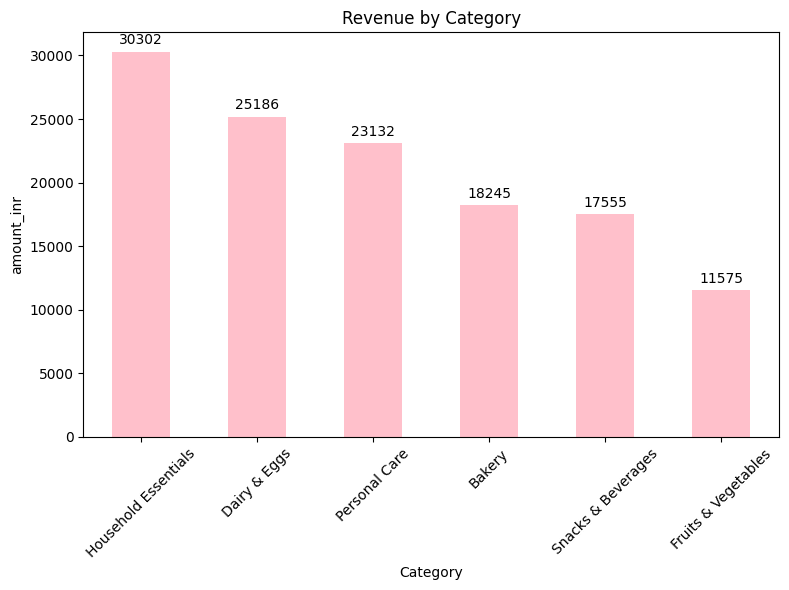

In [55]:
import matplotlib.pyplot as plt

# Sum revenue for each category
revenue_by_category = (
    merged_df.groupby('category')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

# Create bar chart
ax = revenue_by_category.plot(
    kind='bar',
    figsize=(8, 6),
    color='pink'
)

# Add revenue value on top of each bar
ax.bar_label(
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.xlabel('Category')
plt.ylabel('amount_inr')
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


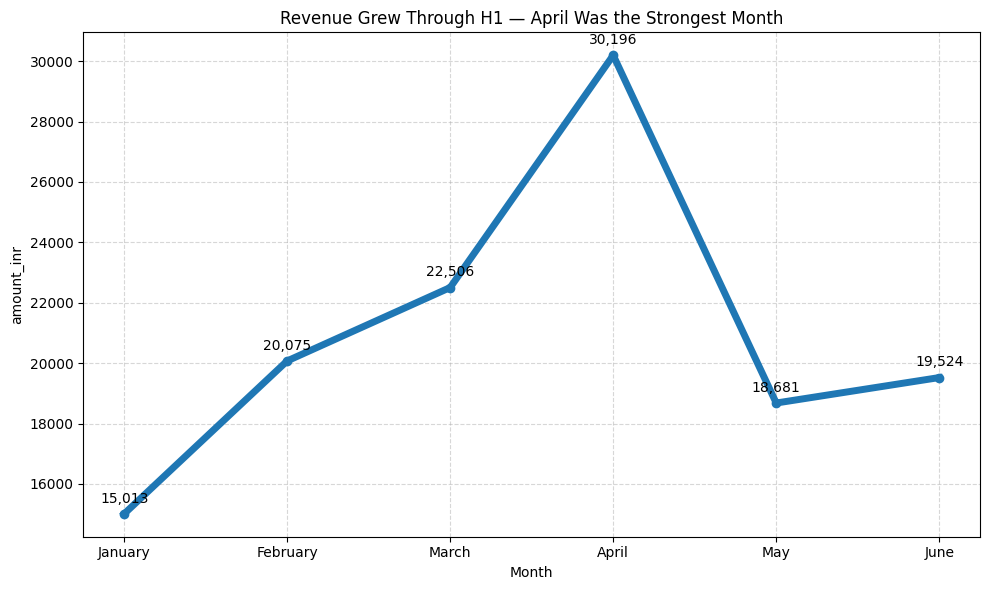

In [61]:
import matplotlib.pyplot as plt

# Define the correct month order
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June'
]

# Aggregate revenue by month
monthly_revenue = (
    merged_df.groupby('month_name')['amount_inr']
    .sum()
    .reindex(month_order)
)

# Create line chart
ax = monthly_revenue.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    linewidth=5
)

# Add revenue values on each point
for x, y in enumerate(monthly_revenue):
    ax.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

plt.xlabel('Month')
plt.ylabel('amount_inr')
plt.title('Revenue Grew Through H1 — April Was the Strongest Month')
plt.xticks(range(len(month_order)), month_order)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

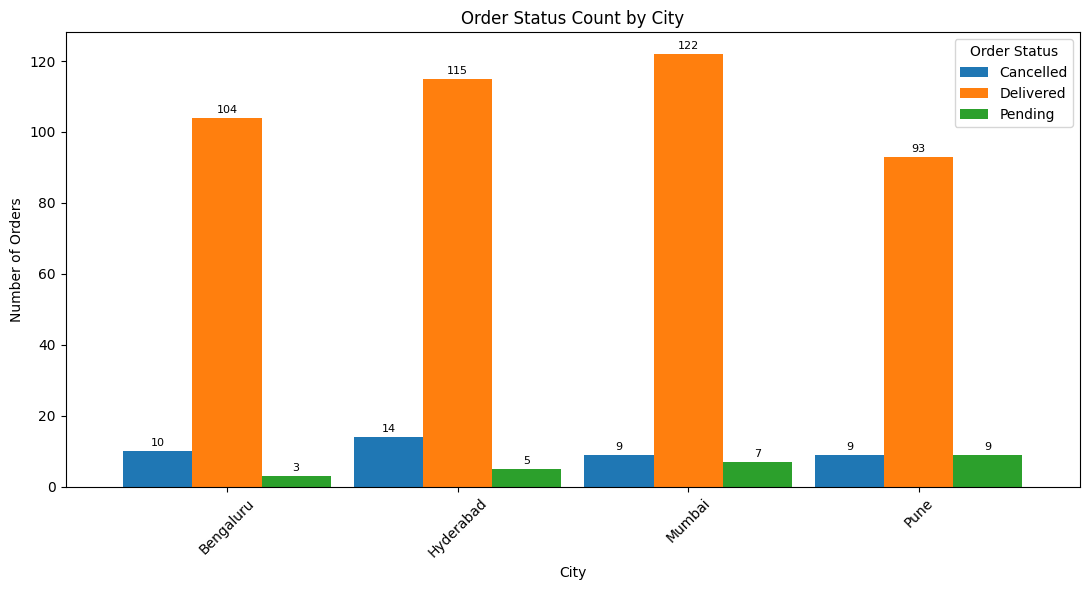

In [60]:
# Grouped bar chart

import matplotlib.pyplot as plt

city_status_counts = (
    merged_df.groupby(['city', 'status'])
    .size()
    .unstack(fill_value=0)
)

ax = city_status_counts.plot(
    kind='bar',
    figsize=(11, 6),
    width=0.9
)

# Add count labels to each bar
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.title('Order Status Count by City')
plt.xticks(rotation=45)
plt.legend(title='Order Status')
plt.tight_layout()
plt.show()

# TASK 9 - WRITTEN OBSERVATIONS

OBSERVATION 1 - REVENUE TREND
WHAT - In the 6 months from Jan to June 2026 revenue has grown quickly and then slowed down too.
The peak business month was April 2026(30196).
From late winter (January) the revenue went up, reached its peak and then fell down.
SO WHAT -Since the products are farm/agriculture based this could indicate quite a few things.
Perhaps Shelf life, agriculture harvesting season, whether the product is consumed more in the season.
Or it could indicate - new competition in the market, or employee turnover
NEXT STEP - A proper swot analysis, examining both internal and external enviroment, examining each level of management and proper surveys of the review of customers and employees would help to understand what action to take.

OBSERVATION 2 - ORDER_STATUS
WHAT - Mumbai stands at highest position of delivered orders(122) while Pune is at the lowest(93)
However in terms of order efficieny hyderabad is at a good positioning as it has a good cancel to pending ration orders. Therefore it indicates all orders have been delivered.
Pune's cancelled : pending(9:9) is  equivalent.

SO WHAT - The order status helps the user to understand the supply chain and the distribution channels of each city properly. Pune has the least pending (3) which shows it's distribution channels are efficient.
Hyderbad has a high number of cancelled order(14), perhaps the service is not liked by people, or they face issues during purchase of such stock in trade items. Perhaps the interface is not friendly.


NEXT STEP - Proper analysis of the supply chain and distribution channel, and delievery in charges' experiences will help to understand why the orders are pending. Mumbai's distribution channel should be adopted in other cities. Pune needs to work on its system.




OBSERVATION 3 - REVENUE BY CATEGORY
Homeessential items generate much more revenue (30302) and vegetables generate the least (11575)

so what - This helps to understand-
shelf life,
in demand products,
help to reorganise the system every season and bring improvements,

next step - Vegetables and fruits channel should be inspected, why is the revenue so short? perhaps shelf life or inflation in the market.
home essentials will have good durability and dairy and eggs is used by many sectors in the economy, their growth and expansion is possible so the business should allocate its resources towards these two areas to expand the business.
Personal care stands at third which is also a good position since they are high in demand products but at the same time there is a lot of competetion like from Nykaa or Blinkit(which also delivers beauty products). With right efforts,progress can be made here too.
